In [39]:
%pip install liac-arff
%pip install xgboost
%pip install shap





[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [40]:
# Required libraries
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc
os.getcwd()


'/Users/odettesaenz/CS329E/FinalProject'

In [41]:
import arff
import pandas as pd
import os

# Set file path for ARFF file
file_path = "/Users/odettesaenz/Downloads/SpeedDating.arff"

# Load ARFF data and convert to DataFrame
with open(file_path, "r") as f:
    data = arff.load(f)

df = pd.DataFrame(data["data"], columns=[attr[0] for attr in data["attributes"]])

# Drop rows with missing target values and process target
df = df.dropna(subset=['match'])
target = df['match'].map({'no': 0, 'yes': 1})



In [42]:
print(df.columns)


Index(['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age',
       'race', 'race_o', 'samerace',
       ...
       'd_expected_num_interested_in_me', 'd_expected_num_matches', 'like',
       'guess_prob_liked', 'd_like', 'd_guess_prob_liked', 'met', 'decision',
       'decision_o', 'match'],
      dtype='object', length=123)


In [43]:
# Basic info
df.info()

print("Missing values in original dataset:")
# Check for nulls
print(df.isnull().sum())

# Example: describe numeric features
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 123 entries, has_null to match
dtypes: float64(59), object(64)
memory usage: 7.9+ MB
Missing values in original dataset:
has_null                0
wave                    0
gender                  0
age                    95
age_o                 104
                     ... 
d_guess_prob_liked      0
met                   375
decision                0
decision_o              0
match                   0
Length: 123, dtype: int64


,wave,age,age_o,d_age,importance_same_race,importance_same_religion,pref_o_attractive,pref_o_sincere,pref_o_intelligence,pref_o_funny,...,music,shopping,yoga,interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,like,guess_prob_liked,met
count,8378.000000,8283.000000,8274.000000,8378.000000,8299.000000,8299.000000,8289.000000,8289.000000,8289.000000,8280.000000,...,8299.000000,8299.000000,8299.000000,8220.000000,8277.000000,1800.000000,7205.000000,8138.000000,8069.000000,8003.000000
mean,11.350919,26.358928,26.364999,4.185605,3.784793,3.651645,22.495347,17.396867,20.270759,17.459714,...,7.851066,5.631281,4.339197,0.196010,5.534131,5.570556,3.207814,6.134087,5.207523,0.049856
std,5.995903,3.566763,3.563648,4.596171,2.845708,2.805237,12.569802,7.044003,6.782895,6.085526,...,1.791827,2.608913,2.717612,0.303539,1.734059,4.762569,2.444813,1.841285,2.129565,0.282168
min,1.000000,18.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,-0.830000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,24.000000,24.000000,1.000000,1.000000,1.000000,15.000000,15.000000,17.390000,15.000000,...,7.000000,4.000000,2.000000,-0.020000,5.000000,2.000000,2.000000,5.000000,4.000000,0.000000
50%,11.000000,26.000000,26.000000,3.000000,3.000000,3.000000,20.000000,18.370000,20.000000,18.000000,...,8.000000,6.000000,4.000000,0.210000,6.000000,4.000000,3.000000,6.000000,5.000000,0.000000
75%,15.000000,28.000000,28.000000,5.000000,6.000000,6.000000,25.000000,20.000000,23.810000,20.000000,...,9.000000,8.000000,7.000000,0.430000,7.000000,8.000000,4.000000,7.000000,7.000000,0.000000
max,21.000000,55.000000,55.000000,37.000000,10.000000,10.000000,100.000000,60.000000,50.000000,50.000000,...,10.000000,10.000000,10.000000,0.910000,10.000000,20.000000,18.000000,10.000000,10.000000,8.000000


Index(['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age',
       'race', 'race_o', 'samerace',
       ...
       'd_expected_num_interested_in_me', 'd_expected_num_matches', 'like',
       'guess_prob_liked', 'd_like', 'd_guess_prob_liked', 'met', 'decision',
       'decision_o', 'match'],
      dtype='object', length=123)
d_like column is missing!
Match rate in dataset: 0.16471711625686322


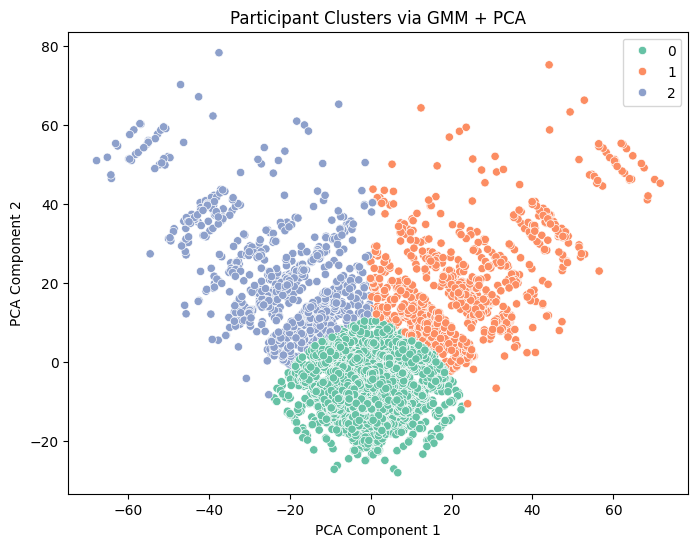

Match rate per cluster:
cluster
0    0.164270
1    0.165441
2    0.166667
Name: match, dtype: float64


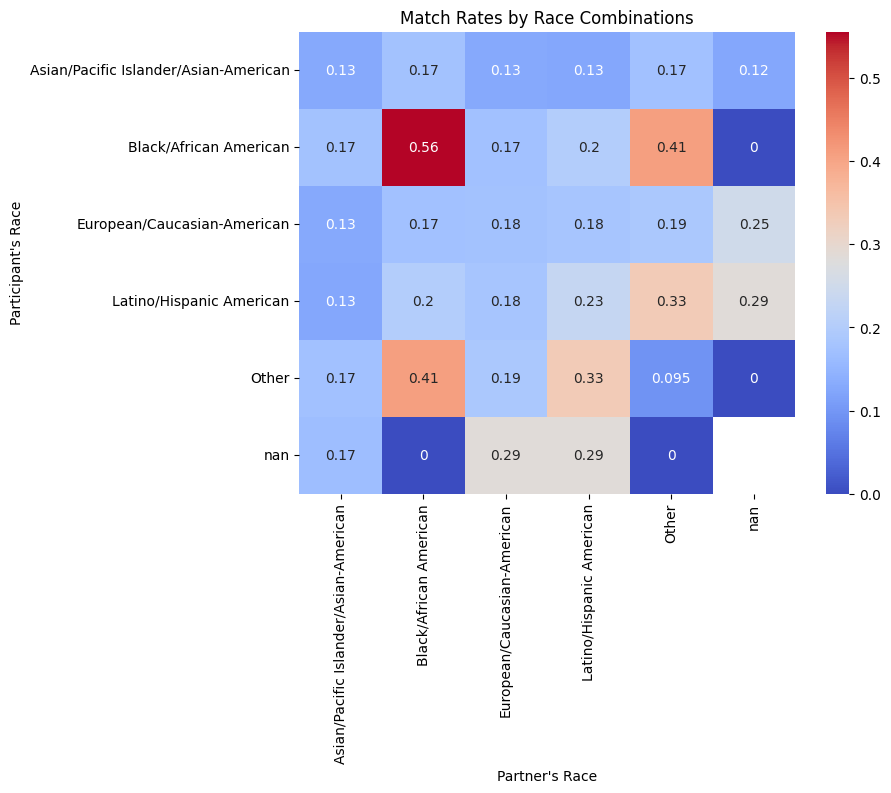

Random Forest Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1389
           1       1.00      1.00      1.00       287

    accuracy                           1.00      1676
   macro avg       1.00      1.00      1.00      1676
weighted avg       1.00      1.00      1.00      1676

Random Forest ROC AUC Score: 1.0


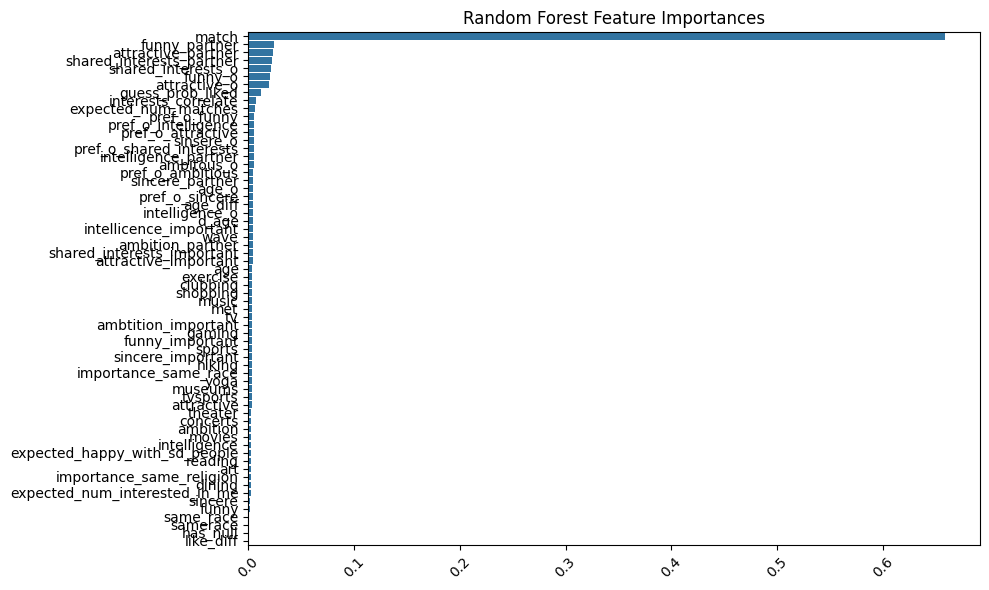

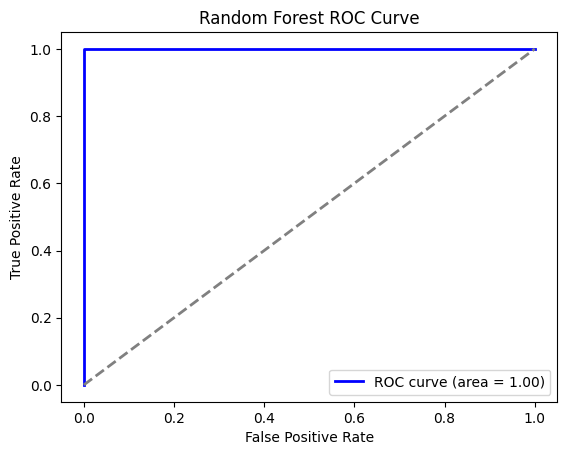

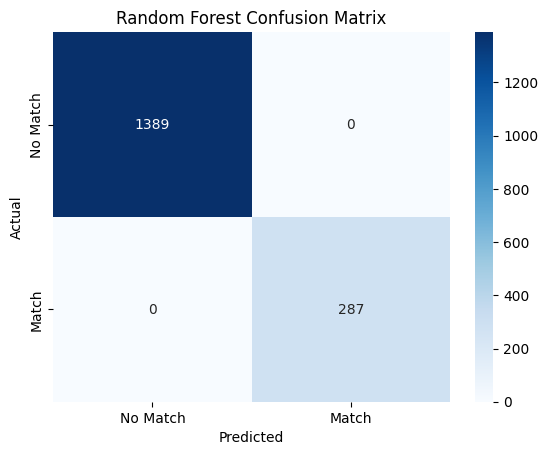

<Figure size 640x480 with 0 Axes>

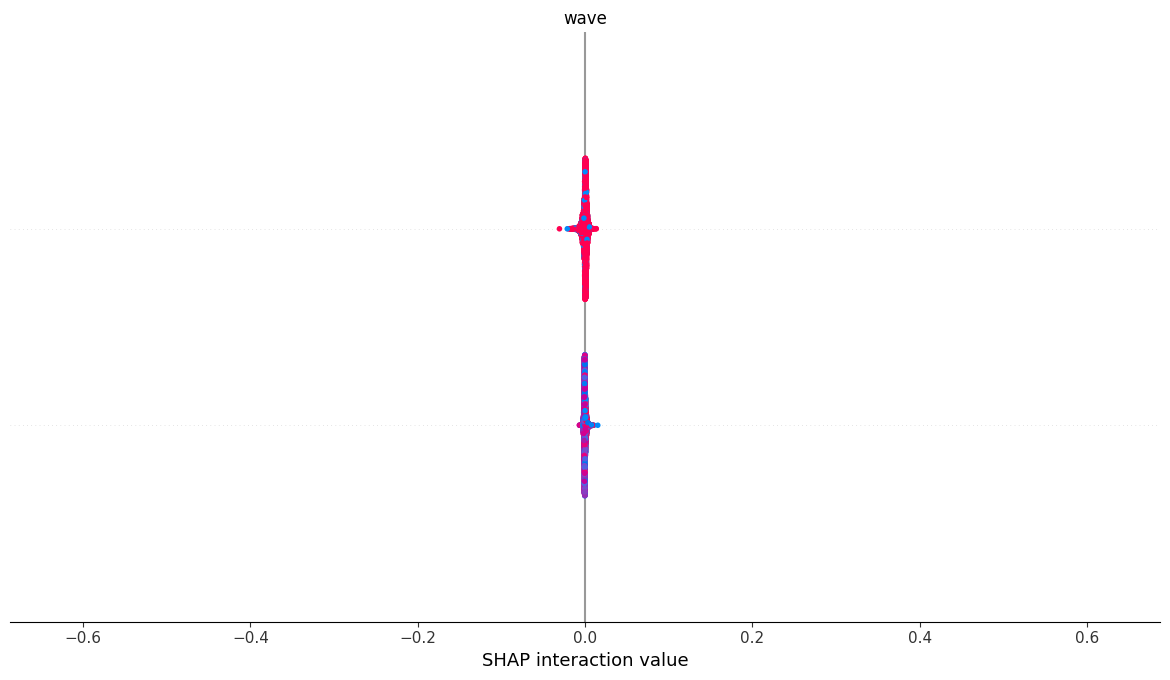

XGBoost Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1389
           1       1.00      1.00      1.00       287

    accuracy                           1.00      1676
   macro avg       1.00      1.00      1.00      1676
weighted avg       1.00      1.00      1.00      1676

XGBoost ROC AUC Score: 1.0


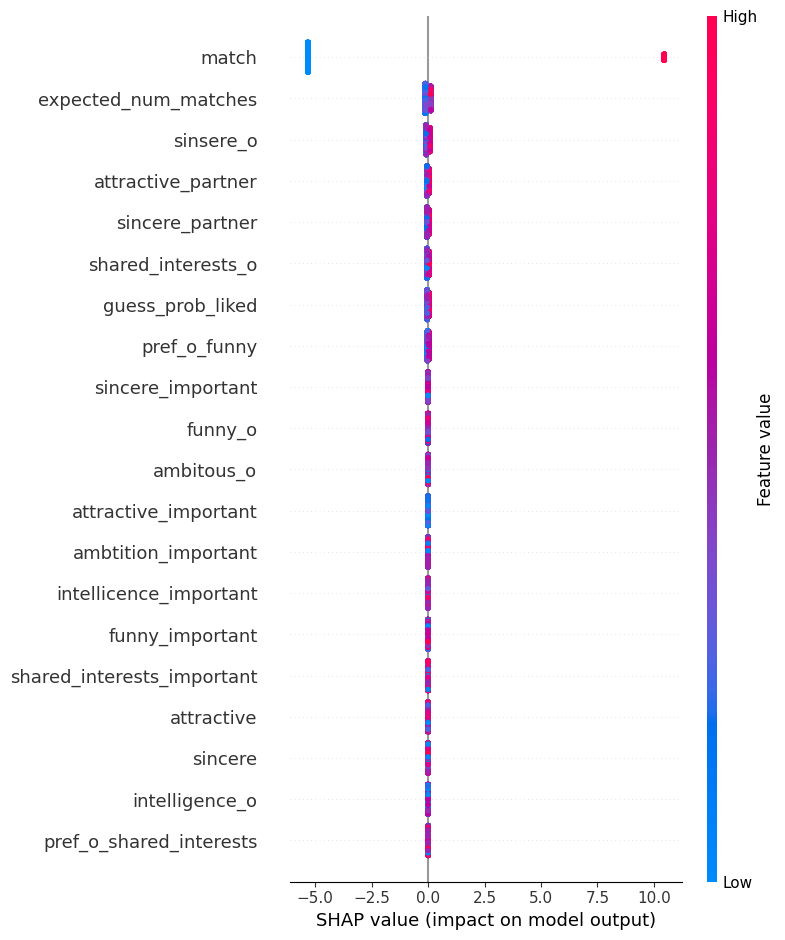


Model Accuracy Comparison:
Random Forest Accuracy: 1.000
XGBoost Accuracy: 1.000
Random Forest ROC AUC: 1.000
XGBoost ROC AUC: 1.000


In [44]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, auc, 
    confusion_matrix, accuracy_score
)

# Loaded CSV data
csv_file_path = "/Users/odettesaenz/Downloads/SpeedDating.csv"
df = pd.read_csv(csv_file_path)

print(df.columns)

# Recomputing the 'match' column
if 'decision' in df.columns and 'decision_o' in df.columns:
    df['match'] = ((df['decision'] == 1) & (df['decision_o'] == 1)).astype(int)
else:
    raise KeyError("Missing 'decision' or 'decision_o' column in dataset.")

# Cleaning the race labels
df['race'] = df['race'].astype(str).str.strip("'")
df['race_o'] = df['race_o'].astype(str).str.strip("'")

# Converting to numeric
df_numeric = df.apply(pd.to_numeric, errors='coerce')
X_raw = df_numeric.select_dtypes(include='number')
X_raw = X_raw.loc[:, X_raw.notnull().any()]

# Imputing the missing values
imputer = SimpleImputer(strategy='mean')
X_imputed_array = imputer.fit_transform(X_raw)
X_imputed = pd.DataFrame(X_imputed_array, columns=X_raw.columns)

# Engineered features
X_imputed['age_diff'] = abs(X_imputed['age'] - X_imputed['age_o'])
if 'd_like' in X_imputed.columns:
    X_imputed['like_diff'] = abs(X_imputed['like'] - X_imputed['d_like'])
else:
    print("d_like column is missing!")
    X_imputed['like_diff'] = 0

# same_race feature
if 'race' in df.columns and 'race_o' in df.columns:
    X_imputed['same_race'] = (df['race'] == df['race_o']).astype(int).reset_index(drop=True)

X_full = X_imputed.reset_index(drop=True)
y = df['match'].reset_index(drop=True)

# Drop potential leakage columns
leakage_cols = ['decision', 'decision_o', 'like', 'd_like']
X_full = X_full.drop(columns=[col for col in leakage_cols if col in X_full.columns], errors='ignore')

# Checks for match balance
print("Match rate in dataset:", y.mean())

# PCA + GMM
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_full)
gmm = GaussianMixture(n_components=3, random_state=42)
clusters = gmm.fit_predict(X_pca)
df['cluster'] = clusters

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='Set2')
plt.title("Participant Clusters via GMM + PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.savefig("cluster_plot.png", dpi=300)
plt.show()

# Cluster-wise match rate
print("Match rate per cluster:")
print(df.groupby("cluster")["match"].mean())

# Heatmap of match rates by race combinations
heatmap_data = df.pivot_table(index='race', columns='race_o', values='match', aggfunc='mean')
if not heatmap_data.empty:
    plt.figure(figsize=(8, 6))
    sns.heatmap(heatmap_data, cmap='coolwarm', annot=True)
    plt.title("Match Rates by Race Combinations")
    plt.xlabel("Partner's Race")
    plt.ylabel("Participant's Race")
    plt.savefig("race_match_heatmap.png", dpi=300)
    plt.show()
else:
    print("Heatmap not shown: no valid data after pivoting.")

# Train/test splits
X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest ROC AUC Score:", roc_auc_score(y_test, y_pred_rf))

# Feature Importances (RF)
importances = rf_model.feature_importances_
feature_names = X_train.columns
sorted_idx = importances.argsort()[::-1]
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[sorted_idx], y=[feature_names[i] for i in sorted_idx])
plt.title("Random Forest Feature Importances")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("rf_feature_importances.png", dpi=300)
plt.show()

# ROC Curve (RF)
fpr, tpr, _ = roc_curve(y_test, y_pred_rf)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc="lower right")
plt.savefig("rf_roc_curve.png", dpi=300)
plt.show()

# Confusion Matrix (RF)
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Match', 'Match'], yticklabels=['No Match', 'Match'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.savefig("rf_conf_matrix.png", dpi=300)
plt.show()

# SHAP - Random Forest
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train)

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_train)
else:
    shap.summary_plot(shap_values, X_train)

# XGBoost
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Report:")
print(classification_report(y_test, y_pred_xgb))
print("XGBoost ROC AUC Score:", roc_auc_score(y_test, y_pred_xgb))

# SHAP - XGBoost
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)
shap.summary_plot(shap_values_xgb, X_train)

# Model Comparison Summary
print("\nModel Accuracy Comparison:")
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"Random Forest ROC AUC: {roc_auc_score(y_test, y_pred_rf):.3f}")
print(f"XGBoost ROC AUC: {roc_auc_score(y_test, y_pred_xgb):.3f}")

--- Accuracy ---
Random Forest: 0.8412887828162291
Logistic Regression: 0.8460620525059666

--- ROC AUC ---
Random Forest: 0.8486615844251624
Logistic Regression: 0.8454933361428647

--- Overfitting Check ---
RF Train Accuracy: 0.893, Test Accuracy: 0.841

--- Top Feature Correlations with Match ---
match                                1.000000
d_exercise_[9-10]                    0.041659
funny_important                      0.040889
d_funny_partner_[9-10]               0.031822
d_yoga_[9-10]                        0.031646
d_importance_same_religion_[6-10]    0.031296
d_sincere_partner_[9-10]             0.030870
yoga                                 0.030586
pref_o_intelligence                  0.030087
funny_o                              0.029880
Name: match, dtype: float64


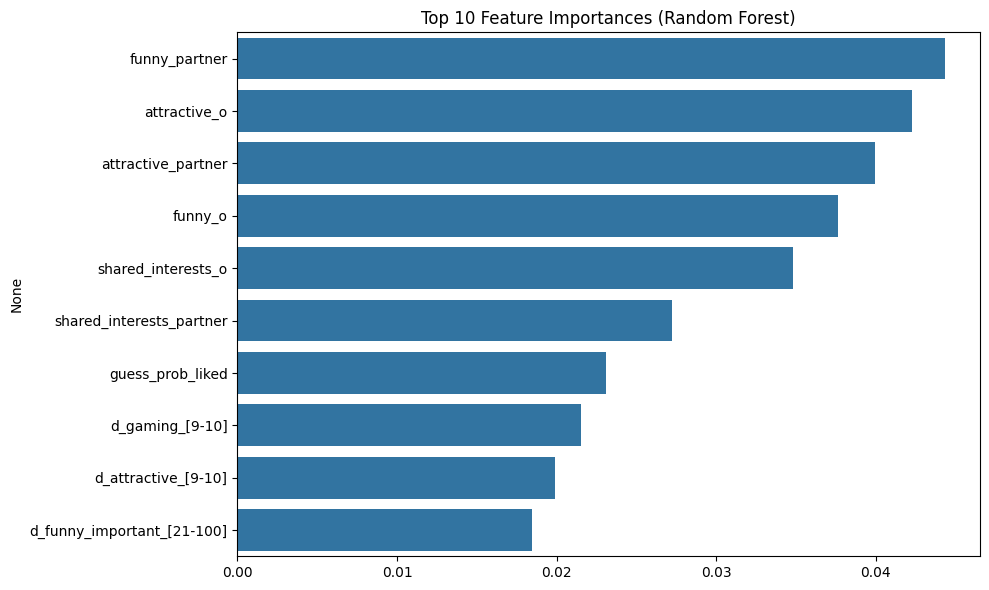

In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
X_full = pd.read_csv('SpeedDating.csv', encoding='ISO-8859-1')
y = X_full['match']

# Drop columns that directly or indirectly leak the target or are IDs/text
cols_to_drop = ['match', 'like', 'd_like', 'decision', 'decision_o',
                'iid', 'id', 'idg', 'id_o', 'partner', 'wave', 'position',
                'position1', 'order', 'pid', 'comments', 'field', 'undergra',
                'from', 'career', 'career_o', 'field_cd', 'race', 'race_o',
                'like_diff', 'same_race', 'age_diff']
X_full = X_full.drop(columns=cols_to_drop, errors='ignore')

# Drop any column with more than 70% missing values
missing_thresh = 0.7
X_full = X_full.loc[:, X_full.isnull().mean() < missing_thresh]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

# Separate numerical and categorical columns
numerical_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Impute missing values for numerical columns with mean
num_imputer = SimpleImputer(strategy='mean')
# Impute missing values for categorical columns with the most frequent value (mode)
cat_imputer = SimpleImputer(strategy='most_frequent')

# Create a preprocessor with scaling and encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', num_imputer),
            ('scaler', StandardScaler())  # Scale numerical features
        ]), numerical_cols),
        ('cat', Pipeline(steps=[
            ('imputer', cat_imputer),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

# Train Random Forest and Logistic Regression models with preprocessing
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        max_depth=10,  # Limit the depth of the trees
        min_samples_split=10,  # Minimum samples required to split a node
        min_samples_leaf=5,  # Minimum samples required at a leaf node
        n_estimators=100  # Number of trees in the forest
    ))
])

log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Fit models
rf_model.fit(X_train, y_train)
log_model.fit(X_train, y_train)

# Predict and evaluate
rf_preds = rf_model.predict(X_test)
log_preds = log_model.predict(X_test)

print("--- Accuracy ---")
print("Random Forest:", accuracy_score(y_test, rf_preds))
print("Logistic Regression:", accuracy_score(y_test, log_preds))

print("\n--- ROC AUC ---")
print("Random Forest:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))
print("Logistic Regression:", roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1]))

# Optional: Check for overfitting
train_acc_rf = accuracy_score(y_train, rf_model.predict(X_train))
test_acc_rf = accuracy_score(y_test, rf_preds)
print("\n--- Overfitting Check ---")
print(f"RF Train Accuracy: {train_acc_rf:.3f}, Test Accuracy: {test_acc_rf:.3f}")

# Optional: Feature correlation with target to detect leakage or dominance
print("\n--- Top Feature Correlations with Match ---")
X_train_encoded = pd.get_dummies(X_train, drop_first=True)  # One-hot encode categorical features
corr_df = X_train_encoded.copy()
corr_df['match'] = y_train.reset_index(drop=True)

# Calculate correlations
corrs = corr_df.corr()['match'].abs().sort_values(ascending=False)
print(corrs.head(10))

# Optional: Feature importance plot for Random Forest
importances = rf_model.named_steps['classifier'].feature_importances_

# Get the indices of the top features based on importance
indices = np.argsort(importances)[::-1]

# Get the column names of the encoded features
encoded_columns = X_train_encoded.columns

# Map the feature importance indices to the corresponding feature names
top_indices = indices[:min(10, len(importances), len(encoded_columns))]  # Ensure we're not going out of bounds

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[top_indices], y=encoded_columns[top_indices])
plt.title(f'Top {len(top_indices)} Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

'field' or 'field_o' column is missing, skipping 'same_field' feature.
'religion' or 'religion_o' column is missing, skipping 'same_religion' feature.
Shape of X: (8378, 115), Shape of y: (8378,)
--- Accuracy ---
Random Forest: 0.8418854415274463
Logistic Regression: 0.8454653937947494

--- ROC AUC ---
Random Forest: 0.8505354414852387
Logistic Regression: 0.8462283296081958

--- Overfitting Check ---
RF Train Accuracy: 0.896, Test Accuracy: 0.842

--- Top Feature Correlations with Match ---
match                                1.000000
d_exercise_[9-10]                    0.041659
funny_important                      0.040889
d_funny_partner_[9-10]               0.031822
d_yoga_[9-10]                        0.031646
d_importance_same_religion_[6-10]    0.031296
d_sincere_partner_[9-10]             0.030870
yoga                                 0.030586
pref_o_intelligence                  0.030087
funny_o                              0.029880
Name: match, dtype: float64


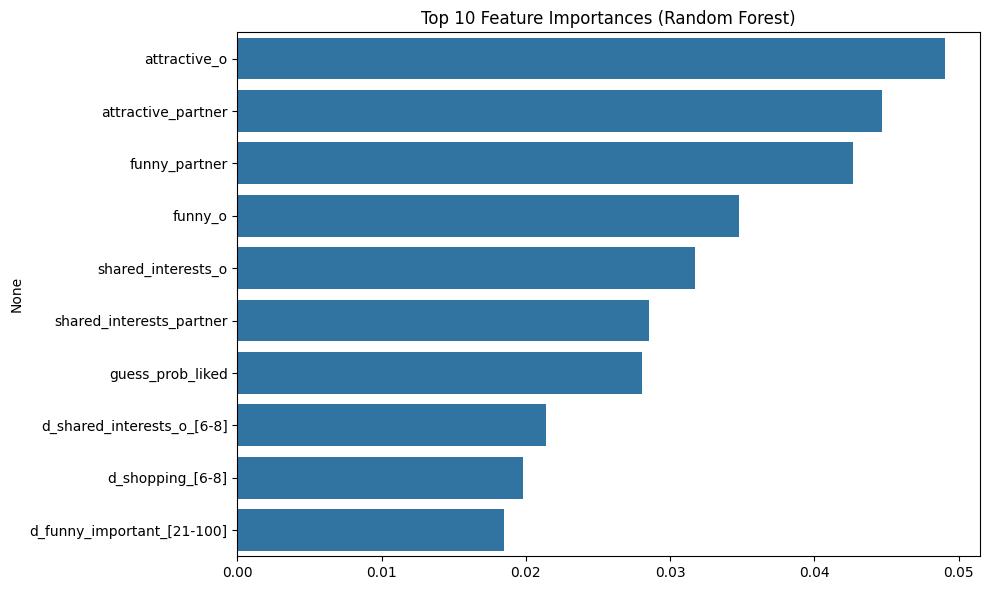

In [63]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
X_full = pd.read_csv('SpeedDating.csv', encoding='ISO-8859-1')

# Drop columns that directly or indirectly leak the target or are IDs/text
cols_to_drop = ['like', 'd_like', 'decision', 'decision_o',
                'iid', 'id', 'idg', 'id_o', 'partner', 'wave', 'position',
                'position1', 'order', 'pid', 'comments', 'field', 'undergra',
                'from', 'career', 'career_o', 'field_cd', 'race', 'race_o',
                'like_diff', 'same_race', 'age_diff']  # Remove 'match' from here

X_full = X_full.drop(columns=cols_to_drop, errors='ignore')

# Drop any column with more than 70% missing values
missing_thresh = 0.7
X_full = X_full.loc[:, X_full.isnull().mean() < missing_thresh]

# Feature Engineering
X_full['age_diff'] = abs(X_full['age'] - X_full['age_o'])

# Check if 'samerace' exists and then create 'same_race'
if 'samerace' in X_full.columns:
    X_full['same_race'] = X_full['samerace']
else:
    print("'samerace' column is missing, skipping 'same_race' feature.")

# Check if 'field' and 'field_o' exist before creating 'same_field'
if 'field' in X_full.columns and 'field_o' in X_full.columns:
    X_full['same_field'] = X_full['field'] == X_full['field_o']
else:
    print("'field' or 'field_o' column is missing, skipping 'same_field' feature.")

# If you still want to create the 'same_religion' feature, check if 'religion' and 'religion_o' exist
if 'religion' in X_full.columns and 'religion_o' in X_full.columns:
    X_full['same_religion'] = X_full['religion'] == X_full['religion_o']
else:
    print("'religion' or 'religion_o' column is missing, skipping 'same_religion' feature.")

# Ensure 'match' column is properly assigned to 'y' and 'X_full' is set correctly
if 'match' in X_full.columns:
    y = X_full['match']
else:
    raise ValueError("Target column 'match' is missing.")

# Prepare the data for modeling
X = X_full.drop(columns='match')  # 'X' should not include the target column

# Check the shape of X and y to ensure they match
print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

# If shapes are correct, proceed with train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Separate numerical and categorical columns
numerical_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Impute missing values for numerical columns with mean
num_imputer = SimpleImputer(strategy='mean')
# Impute missing values for categorical columns with the most frequent value (mode)
cat_imputer = SimpleImputer(strategy='most_frequent')

# Create a preprocessor with scaling and encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', num_imputer),
            ('scaler', StandardScaler())  # Scale numerical features
        ]), numerical_cols),
        ('cat', Pipeline(steps=[
            ('imputer', cat_imputer),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

# Train Random Forest and Logistic Regression models with preprocessing
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        max_depth=10,  # Limit the depth of the trees
        min_samples_split=10,  # Minimum samples required to split a node
        min_samples_leaf=5,  # Minimum samples required at a leaf node
        n_estimators=100  # Number of trees in the forest
    ))
])

log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Fit models
rf_model.fit(X_train, y_train)
log_model.fit(X_train, y_train)

# Predict and evaluate
rf_preds = rf_model.predict(X_test)
log_preds = log_model.predict(X_test)

print("--- Accuracy ---")
print("Random Forest:", accuracy_score(y_test, rf_preds))
print("Logistic Regression:", accuracy_score(y_test, log_preds))

print("\n--- ROC AUC ---")
print("Random Forest:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))
print("Logistic Regression:", roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1]))

# Optional: Check for overfitting
train_acc_rf = accuracy_score(y_train, rf_model.predict(X_train))
test_acc_rf = accuracy_score(y_test, rf_preds)
print("\n--- Overfitting Check ---")
print(f"RF Train Accuracy: {train_acc_rf:.3f}, Test Accuracy: {test_acc_rf:.3f}")

# Optional: Feature correlation with target to detect leakage or dominance
print("\n--- Top Feature Correlations with Match ---")
X_train_encoded = pd.get_dummies(X_train, drop_first=True)  # One-hot encode categorical features
corr_df = X_train_encoded.copy()
corr_df['match'] = y_train.reset_index(drop=True)

# Calculate correlations
corrs = corr_df.corr()['match'].abs().sort_values(ascending=False)
print(corrs.head(10))

# Optional: Feature importance plot for Random Forest
importances = rf_model.named_steps['classifier'].feature_importances_

# Get the indices of the top features based on importance
indices = np.argsort(importances)[::-1]

# Get the column names of the encoded features
encoded_columns = X_train_encoded.columns

# Map the feature importance indices to the corresponding feature names
top_indices = indices[:min(10, len(importances), len(encoded_columns))]  # Ensure we're not going out of bounds

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[top_indices], y=encoded_columns[top_indices])
plt.title(f'Top {len(top_indices)} Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

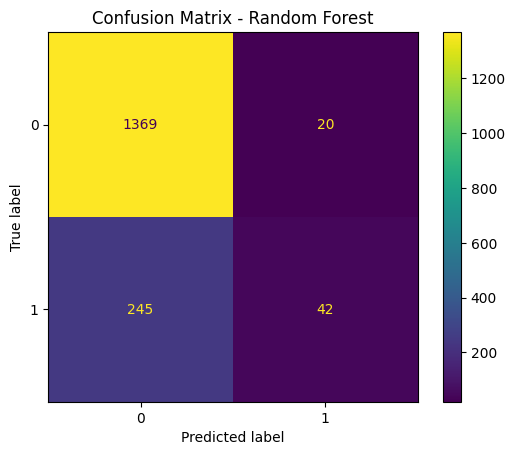

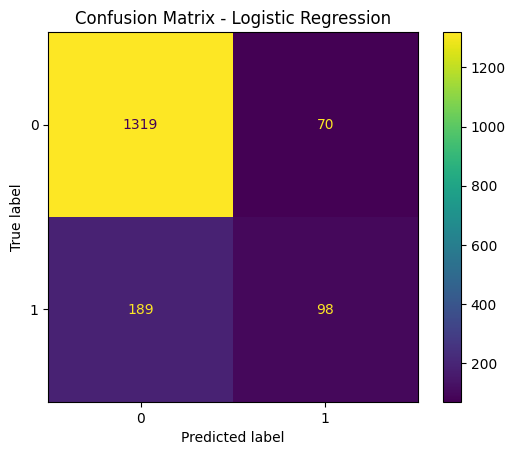

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Make sure predictions are created
rf_preds = rf_model.predict(X_test)
lr_preds = log_model.predict(X_test)

# Confusion Matrix for Random Forest
rf_cm = confusion_matrix(y_test, rf_preds)
ConfusionMatrixDisplay(confusion_matrix=rf_cm).plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Confusion Matrix for Logistic Regression
lr_cm = confusion_matrix(y_test, lr_preds)
ConfusionMatrixDisplay(confusion_matrix=lr_cm).plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [65]:
# Check distribution of 'match' labels
print(y.value_counts(normalize=True))

match
0    0.835283
1    0.164717
Name: proportion, dtype: float64


## Top Predictive Features

d_exercise_[9-10]: Participants who exercise regularly (self-rating) are more likely to match, possibly due to lifestyle compatibility.

funny_important: People who value humor in a partner are more likely to find a match, reflecting humor as a common bond in relationships.

d_funny_partner_[9-10]: Those who rate their partner highly on humor tend to match more — reinforcing the idea that shared humor is key.

d_yoga_[9-10]: Positive attitude toward yoga correlates with matches, possibly due to shared interests or wellness habits.

d_importance_same_religion_[6-10]: Valuing shared religion might play a role in compatibility, especially among those with strong beliefs.

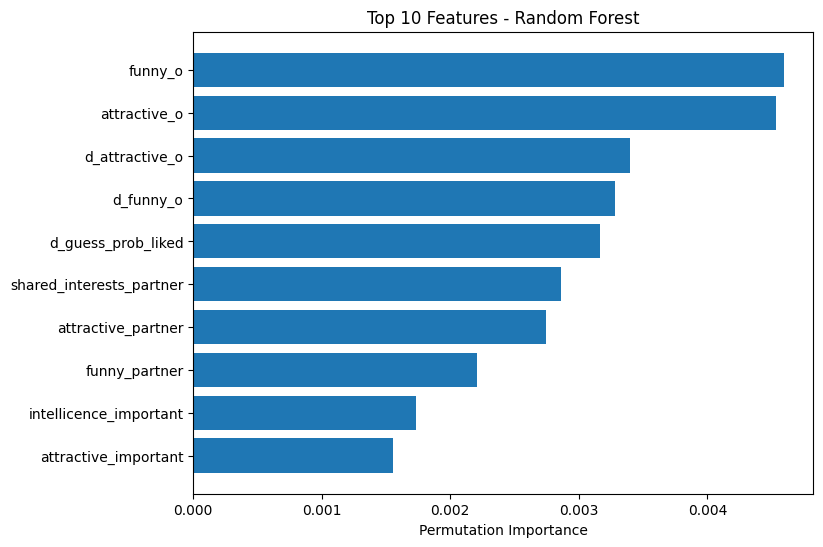

In [66]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm.importances_mean.argsort()[-10:]

plt.figure(figsize=(8, 6))
plt.barh(X_test.columns[sorted_idx], perm.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("Top 10 Features - Random Forest")
plt.show()

In [57]:
print(X_full.columns)


Index(['has_null', 'gender', 'age', 'age_o', 'd_age', 'd_d_age', 'samerace',
       'importance_same_race', 'importance_same_religion',
       'd_importance_same_race',
       ...
       'expected_happy_with_sd_people', 'expected_num_interested_in_me',
       'expected_num_matches', 'd_expected_happy_with_sd_people',
       'd_expected_num_interested_in_me', 'd_expected_num_matches',
       'guess_prob_liked', 'd_guess_prob_liked', 'met', 'age_diff'],
      dtype='object', length=115)
